In [2]:
# Ethan Stroberg
# National Severe Storms Laboratory
# objective: read in csv file containing sonde flight data and plot altitude vs time, frame num vs time, particle num vs time
# also plot temp v altidue, RH/dew v altitude etc ... maybe run a skewT?
# last edited Feb 19, 2025
import pandas as pd
import matplotlib.pyplot as plt
import h5py

In [3]:
# create any relevant functions
# frame_extractor: extracts the image frame from the list of filenames in the IOP10 file
def frame_extractor(filename):
    parts = filename.split('_')
    frame_number = parts[-1].split('.')[0]
    return frame_number

# time_extractor: extracts the time of day from the list of filenames in the IOP10 file and converts to HH:MM:SS format
def time_extractor(filename):
    parts = filename.split('_')
    time_list = parts[0].split('-')[-3:]
    time_colon_format = ":".join(map(str, time_list))
    return time_colon_format

In [6]:

# read the csv into a dataframe
df = pd.read_csv("NSSL1_MW41_output_20230201_185158.csv")
# convert the GPS Time Record row to a datetime object consisting only of the HHMMSS time (cleaner, no reason for a date)
# strip any leading or trailing whitespace
df["GPS Time Record      "] = df["GPS Time Record      "].str.strip() 
# establish current format and convert
df["GPS Time Record      "] = pd.to_datetime(df["GPS Time Record      "], format = '%d-%b-%Y %H:%M:%S')
df['GPS Time Record      '] = df['GPS Time Record      '].dt.strftime('%H:%M:%S')
df.rename(columns={'GPS Time Record      ': 'GPS Time Record'}, inplace=True)
display(df)
df.columns

,Date-Time,RadioRxTime,GPS Time Record,Filtered Temperature (K),Filtered Humidity,Filtered Dewpoint (K),Filtered Pressure (mb),Filtered Wind Dir,Filtered Wind Spd (m/s),Filtered Altitude (m),...,WindResults East (m/s),WindResults North (m/s),WindResults Up (m/s),WindResults FiltGeoPotHeight (m),Calculated Mixing Ratio,,.1,.2,.3,Unnamed: 37
0,[2023-02-01T18:55:38.3310673],1617.3864,18:52:34,267.9500,93.1000,267.0068,1076.0000,288.0000,1.2000,67.2906,...,3.8653,1.2694,-32768,107.6283,2.2426,,,,,NaN
1,[2023-02-01T18:55:40.3797844],1618.8020,18:52:35,267.1684,95.9787,266.6292,1009.8919,254.2719,3.7510,77.0437,...,4.2167,1.3909,-32768,112.0211,2.3217,,,,,NaN
2,[2023-02-01T18:55:40.3835557],1619.8020,18:52:36,267.1263,96.3236,266.6343,1009.2648,251.8721,4.7566,82.7187,...,4.5732,1.5130,-32768,117.5496,2.3240,,,,,NaN
3,[2023-02-01T18:55:40.3878288],1620.8020,18:52:37,267.0971,95.8330,266.5383,1008.7607,251.3587,5.3197,87.4098,...,4.9325,1.6339,-32768,122.3632,2.3081,,,,,NaN
4,[2023-02-01T18:55:40.3910535],1621.8020,18:52:38,267.1302,95.0431,266.4629,1008.3276,251.4188,5.6832,91.2978,...,5.2929,1.7530,-32768,125.9768,2.2957,,,,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1058,[2023-02-01T19:10:56.0287827],2675.8010,19:10:12,264.3263,87.7242,262.6495,973.6930,253.1219,13.4834,363.6995,...,12.9027,3.9148,-32768,397.6811,1.7643,,,,,NaN
1059,[2023-02-01T19:10:56.0292128],2676.8010,19:10:13,264.4644,88.5265,262.9019,974.9395,253.2225,13.5239,355.9904,...,12.9486,3.9036,-32768,389.7875,1.7977,,,,,NaN
1060,[2023-02-01T19:10:56.0296612],2677.8010,19:10:14,264.5635,89.3039,263.1114,975.2283,253.2985,13.5631,348.5988,...,12.9916,3.8976,-32768,382.4858,1.8273,,,,,NaN
1061,[2023-02-01T19:10:56.0301064],2678.8010,19:10:15,264.6488,89.9824,263.2925,976.0325,253.3571,13.6008,341.4436,...,13.0314,3.8955,-32768,375.4636,1.8521,,,,,NaN


Index(['Date-Time                     ', 'RadioRxTime ', 'GPS Time Record',
       'Filtered Temperature (K) ', 'Filtered Humidity ',
       'Filtered Dewpoint (K) ', 'Filtered Pressure (mb) ',
       'Filtered Wind Dir ', 'Filtered Wind Spd (m/s) ',
       'Filtered Altitude (m) ', 'Filtered Latitude ', 'Filtered Longitude ',
       'GPS Velocity East (m/s) ', 'GPS Velocity North (m/s) ',
       'GPS Velocity Up (m/s) ', 'GPS Altitude (m) ', 'GPS Latitude ',
       'GPS Longitude ', 'GPS Derived Wind Dir ',
       'GPS Derived Wind Spd (m/s) ', 'PTU Status ', 'RawPTU AscRate (m/s) ',
       'RawPTU Humidity1 ', 'RawPTU Humidity2 ', 'RawPTU Pressure ',
       'RawPTU PressureOK ', 'RawPTU Temperature ', 'RawPTU TemperatureOK ',
       'WindResults East (m/s) ', 'WindResults North (m/s) ',
       'WindResults Up (m/s) ', 'WindResults FiltGeoPotHeight (m) ',
       'Calculated Mixing Ratio ', ' ', ' .1', ' .2', ' .3', 'Unnamed: 37'],
      dtype='object')

In [15]:
# time to add the associated frame numbers to each time
# i'm thinking I'll add the first frame number for that instance because there are many frame numbers for each second
# first, lets open the txt file and read each line into a list of filenames
with open('IOP10_fileList.txt', 'r') as file:
    filenames = file.readlines()
#clean up the list and get rid of extra spaces
filenames = [filename.strip() for filename in filenames]

# extract the frames from the filenames
frame_numbers = [frame_extractor(filename) for filename in filenames]

# extract the time from the filenames and format it as HH:MM:SS
times = [time_extractor(filename) for filename in filenames]

# create the dataframe
frame_df = pd.DataFrame({'GPS Time Record': times, 'Frame': frame_numbers})

# 18:52:34 is #9489 in iop10, index 9490, need to match
frame_df = frame_df.drop(range(0, 9489))

# get rid of all duplicate timestamps in the filename column (each time will now have exactly one frame mapped to it)
frame_df = frame_df.drop_duplicates(subset = 'GPS Time Record', keep = 'first')
frame_df.reset_index(drop = True, inplace = True)
display(frame_df)

,GPS Time Record,Frame
0,18:52:34,09489
1,18:52:35,09522
2,18:52:36,09531
3,18:52:37,09549
4,18:52:38,09578
...,...,...
1522,19:17:56,39924
1523,19:17:57,39935
1524,19:17:58,39955
1525,19:17:59,39984


In [16]:
# # Open the HDF5 file
# with h5py.File('pasive_manualclassification_condensed2.h5', 'r') as f:
#     # Get the list of group names in the HDF5 file
#     group_names = list(f.keys())

# particle_count = 0
# for i in group_names:
#     particle_count += 1

# frames_HDF = [name.split('_')[0] for name in group_names]

# # dataframe with the frame numbers and the particle numbers (starting at 1!)
# hdf_df = pd.DataFrame({'Frame' : frames_HDF})
# hdf_df.drop(range(0, 1827), inplace = True)
# hdf_df.reset_index(drop = True, inplace = True)
# hdf_df['Particle Number'] = hdf_df.index + 1

# # Print the DataFrame
# display(hdf_df)
# print(f"particle count = {particle_count}")

In [17]:
# # merge the HDF and IOP10 dataframes
# intermediate_df = pd.merge(frame_df, hdf_df[['Frame', 'Particle Number']], on = 'Frame', how='right')
# intermediate_df.drop_duplicates(subset = 'GPS Time Record', keep = 'first', inplace = True)
# intermediate_df.dropna(inplace = True)
# intermediate_df.reset_index(drop = True, inplace = True)
# display(intermediate_df)
# print(intermediate_df.shape)

In [18]:
# merge the NSSL file and IOP10 file dataframes based on the aligned timestamps --> add frames to the NSSL df
merged_df = pd.merge(df, frame_df[['GPS Time Record', 'Frame',]], on='GPS Time Record', how='right')
merged_df.drop(0, axis = 0, inplace = True) # drop this first line because there were a handful of slightly anomalous values here
display(merged_df)
print(merged_df.shape)

,Date-Time,RadioRxTime,GPS Time Record,Filtered Temperature (K),Filtered Humidity,Filtered Dewpoint (K),Filtered Pressure (mb),Filtered Wind Dir,Filtered Wind Spd (m/s),Filtered Altitude (m),...,WindResults North (m/s),WindResults Up (m/s),WindResults FiltGeoPotHeight (m),Calculated Mixing Ratio,,.1,.2,.3,Unnamed: 37,Frame
1,[2023-02-01T18:55:40.3797844],1618.802,18:52:35,267.1684,95.9787,266.6292,1009.8919,254.2719,3.7510,77.0437,...,1.3909,-32768.0,112.0211,2.3217,,,,,NaN,09522
2,[2023-02-01T18:55:40.3835557],1619.802,18:52:36,267.1263,96.3236,266.6343,1009.2648,251.8721,4.7566,82.7187,...,1.5130,-32768.0,117.5496,2.3240,,,,,NaN,09531
3,[2023-02-01T18:55:40.3878288],1620.802,18:52:37,267.0971,95.8330,266.5383,1008.7607,251.3587,5.3197,87.4098,...,1.6339,-32768.0,122.3632,2.3081,,,,,NaN,09549
4,[2023-02-01T18:55:40.3910535],1621.802,18:52:38,267.1302,95.0431,266.4629,1008.3276,251.4188,5.6832,91.2978,...,1.7530,-32768.0,125.9768,2.2957,,,,,NaN,09578
5,[2023-02-01T18:55:40.3942923],1622.802,18:52:39,267.1271,94.7284,266.4164,1007.8434,251.5916,6.0038,95.2511,...,1.8689,-32768.0,129.6425,2.2886,,,,,NaN,09593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1526,NaN,NaN,19:17:56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39924
1527,NaN,NaN,19:17:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39935
1528,NaN,NaN,19:17:58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39955
1529,NaN,NaN,19:17:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39984


(1530, 39)


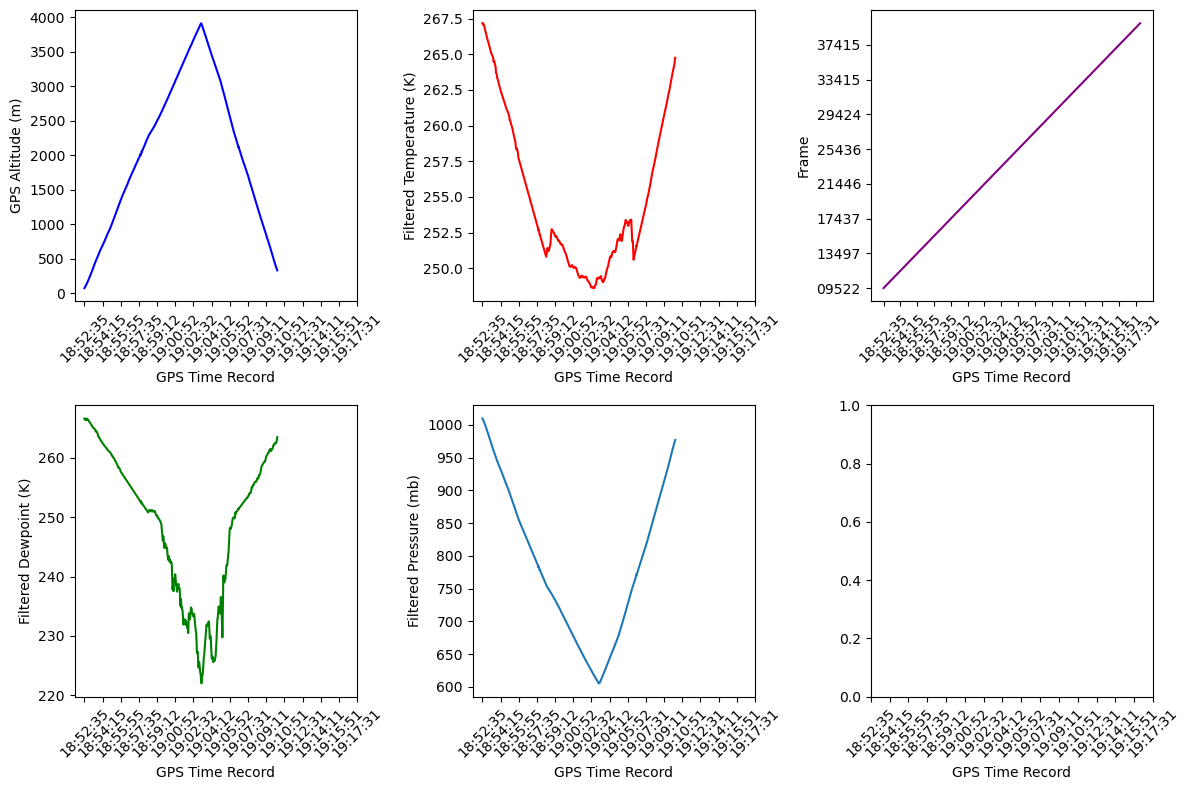

In [19]:
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize=(12, 8))
x = merged_df['GPS Time Record']

ax[0,0].plot(x, merged_df['GPS Altitude (m) '], color = 'b')
ax[0,0].set_ylabel('GPS Altitude (m)')

ax[0,1].plot(x, merged_df['Filtered Temperature (K) '], color = 'r')
ax[0,1].set_ylabel('Filtered Temperature (K)')

ax[1,0].plot(x, merged_df['Filtered Dewpoint (K) '],color = 'g' )
ax[1,0].set_ylabel('Filtered Dewpoint (K)')

ax[1,1].plot(x, merged_df['Filtered Pressure (mb) '])
ax[1,1].set_ylabel('Filtered Pressure (mb)')

ax[0,2].plot(x, merged_df['Frame'], color = 'purple')
ax[0,2].set_ylabel('Frame')
ax4_yticks = range(0, len(merged_df), 200)
ax4_ytick_labels = merged_df['Frame'].iloc[ax4_yticks]
ax[0,2].set_yticks(ax4_yticks, ax4_ytick_labels)

# ax[1,2].plot(x, merged_df['Particle Number'], color = 'brown')
# ax[1,2].set_ylabel('Particle Number')

for axes in ax.flat:
    axes.set_xticks(range(0, len(merged_df), 100), merged_df['GPS Time Record'].iloc[range(0, len(merged_df), 100)], rotation = 45)
    axes.set_xlabel('GPS Time Record')
    
fig.tight_layout()
plt.show()